# E13 · State-space models: let the Kalman filter integrate out the latent states

| | |
|---|---|
| **Type** | Worked example - read, run, modify |
| **Data** | UK road casualties, monthly, January 1969 - December 1984 (192 months), with petrol price, distance driven and the compulsory seat-belt law of 31 January 1983 |
| **You will learn** | Linear-Gaussian state-space models · the Kalman filter as an exact marginal likelihood (10 lines of NumPy) · `pymc_extras.statespace`: structural components, what the package makes you declare, putting priors in `P0` so the filter integrates out coefficients too · Kalman versus brute-force NUTS, measured · decomposition with credible bands · one-step-ahead innovations as the check that matters · an intervention effect, its counterfactual and a negative-control outcome · missing data and forecasting for free · where the approach stops |

Challenge **C07** fits a latent time series the brute-force way: one unknown per day, all of
them handed to NUTS. That is the only option there, because stochastic volatility is not
linear-Gaussian. When a model **is** linear and Gaussian - a level that drifts, a seasonal
pattern that evolves, regression effects, Normal noise - there is a much better deal on
offer. The **Kalman filter** computes the likelihood of the data with every latent state
integrated out *exactly*. NUTS is left with a handful of variance parameters, and the states
are recovered afterwards, also exactly, by the **Kalman smoother**.

The question is a classic of the genre (Harvey & Durbin, 1986): *did the seat-belt law reduce
the number of car drivers killed or seriously injured, and by how much?*

In [1]:
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_extras
import pytensor.tensor as pt
from pymc_extras.statespace import structural as st
from scipy import optimize, stats

from pymc_challenges import data

# Post-estimation sampling compiles a random-number Op that Numba runs in object mode: harmless.
warnings.filterwarnings("ignore", message="Numba will use object mode")

RANDOM_SEED = 1983
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

print(f"PyMC {pm.__version__}, pymc-extras {pymc_extras.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, pymc-extras 0.15.1, ArviZ 1.3.0


## 1 · Question and data

`drivers` is the monthly number of car drivers killed or seriously injured (KSI) in Great
Britain; `rear` is the same for rear-seat passengers, **who were not covered by the 1983
law** - keep them in mind, they will be our negative control. `law` is 0 until January 1983
and 1 for the 23 months from February 1983.

The file's index is a decimal year. The state-space module wants a pandas `DatetimeIndex`
with a frequency (it uses it to label forecasts), so we build one.

In [2]:
data.describe("seatbelts")
belts = data.load("seatbelts")
belts.index = pd.date_range("1969-01-01", periods=len(belts), freq="MS", name="time")
LAW_START = belts.index[belts.law == 1][0]
print(f"{len(belts)} months; law in force from {LAW_START:%B %Y} ({int(belts.law.sum())} months)")
belts.head()

seatbelts: Monthly UK road casualties 1969-1984 with petrol price, distance driven and the Jan 1983 seat-belt law.
  source: Harvey & Durbin (1986), UK Department of Transport, via R `datasets::Seatbelts`.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/datasets/Seatbelts.csv
192 months; law in force from February 1983 (23 months)


,DriversKilled,drivers,front,rear,kms,PetrolPrice,VanKilled,law
time,,,,,,,,
1969-01-01,107,1687,867,269,9059,0.102972,12,0
1969-02-01,97,1508,825,265,7685,0.102363,6,0
1969-03-01,102,1507,806,319,9963,0.102062,12,0
1969-04-01,87,1385,814,407,10955,0.100873,8,0
1969-05-01,119,1632,991,454,11823,0.101020,10,0


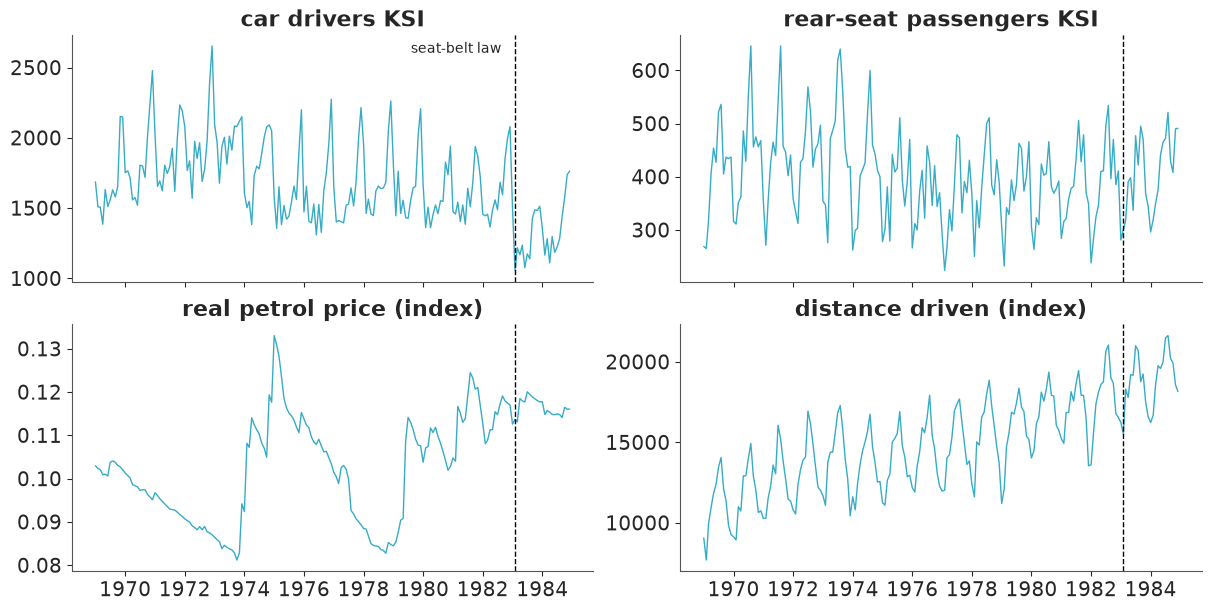

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for ax, col, label in zip(
    axes.flat,
    ["drivers", "rear", "PetrolPrice", "kms"],
    ["car drivers KSI", "rear-seat passengers KSI", "real petrol price (index)", "distance driven (index)"],
):
    ax.plot(belts.index, belts[col], lw=1)
    ax.axvline(LAW_START, color="k", ls="--", lw=1)
    ax.set(title=label)
axes[0, 0].annotate("seat-belt law", (LAW_START, belts.drivers.max()), xytext=(-75, -5),
                    textcoords="offset points", fontsize=10);

Everything that makes the question hard is visible. The series has a strong **seasonal
pattern** (winter peaks), a **level that wanders** (down after the 1973-74 oil crisis, up
again, down again), and explanatory variables that themselves trend: petrol got dearer and
people drove more. After the law the drivers series is lower - but it had been lower in the late
1970s than in the early 1970s too, and single months swing by 30%. A before/after difference in means would confound all of it.

We model `log(drivers)`: effects on road casualties are naturally multiplicative ("10%
fewer"), and on the log scale the seasonal swing has a constant size.

In [4]:
y_drivers = np.log(belts[["drivers"]])
y_rear = np.log(belts[["rear"]])

exog = pd.DataFrame(
    {
        "log_petrol": np.log(belts.PetrolPrice) - np.log(belts.PetrolPrice).mean(),
        "log_kms": np.log(belts.kms) - np.log(belts.kms).mean(),
        "law": belts.law.astype(float),
    }
)
exog.describe().loc[["mean", "std", "min", "max"]].round(3)

,log_petrol,log_kms,law
mean,0.000,0.000,0.120
std,0.120,0.204,0.326
min,-0.237,-0.648,0.000
max,0.257,0.386,1.000


## 2 · The idea, with nothing hidden

The simplest state-space model is the **local level** model. There is one latent state, the
level $\mu_t$, which does a random walk; we observe it with noise:

$$
\begin{aligned}
y_t &= \mu_t + \varepsilon_t, & \varepsilon_t &\sim \text{Normal}(0, \sigma_\varepsilon) && \text{(observation equation)}\\
\mu_{t+1} &= \mu_t + \eta_t, & \eta_t &\sim \text{Normal}(0, \sigma_\eta) && \text{(state equation)}
\end{aligned}
$$

with $\mu_1 \sim \text{Normal}(a_1, P_1)$. There are 192 unknown levels and two unknown standard
deviations. But everything is Gaussian and linear, so the distribution of $\mu_t$ given the
data so far is Gaussian too, and it can be carried forward one observation at a time:

1. **Predict the next observation.** If $\mu_t \mid y_{1:t-1} \sim \text{Normal}(a_t, P_t)$ then
   $y_t \mid y_{1:t-1} \sim \text{Normal}(a_t,\; F_t = P_t + \sigma_\varepsilon^2)$. The surprise
   $v_t = y_t - a_t$ is the **innovation**.
2. **Update.** Move the estimate towards the observation by the Kalman gain $K_t = P_t / F_t$:
   $a_{t|t} = a_t + K_t v_t$, $P_{t|t} = P_t (1 - K_t)$.
3. **Step forward.** $a_{t+1} = a_{t|t}$, $P_{t+1} = P_{t|t} + \sigma_\eta^2$.

Step 1 is the point: multiplying the one-step predictive densities gives
$p(y_{1:T} \mid \sigma_\varepsilon, \sigma_\eta) = \prod_t \text{Normal}(y_t \mid a_t, F_t)$ - the
likelihood of the two parameters with all 192 levels integrated out. No approximation.

In [5]:
def local_level_filter(y, sigma_eps, sigma_eta, a1, P1):
    """Kalman filter for the local level model: log-likelihood, one-step predictions, filtered level."""
    a, P, loglik = a1, P1, 0.0                    # a, P: mean and variance of mu_t given y_1..y_{t-1}
    predicted, filtered = [], []
    for y_t in y:
        v, F = y_t - a, P + sigma_eps**2          # innovation and its variance
        loglik += stats.norm.logpdf(v, 0.0, np.sqrt(F))
        predicted.append(a)
        K = P / F                                 # Kalman gain
        a, P = a + K * v, P * (1 - K)             # update with y_t ...
        filtered.append(a)
        P = P + sigma_eta**2                      # ... and step forward (the mean does not move)
    return loglik, np.array(predicted), np.array(filtered)


y_np = y_drivers["drivers"].to_numpy()
A1, P1 = np.log(1500.0), 0.5**2                   # vague start: somewhere around 1500 a month

loglik, _, _ = local_level_filter(y_np, 0.10, 0.03, A1, P1)
print(f"log-likelihood at sigma_eps=0.10, sigma_eta=0.03: {loglik:.3f}")

log-likelihood at sigma_eps=0.10, sigma_eta=0.03: 93.929


A likelihood of two numbers can be maximised by any optimiser:

maximum likelihood: sigma_eps = 0.047, sigma_eta = 0.109, loglik = 123.6


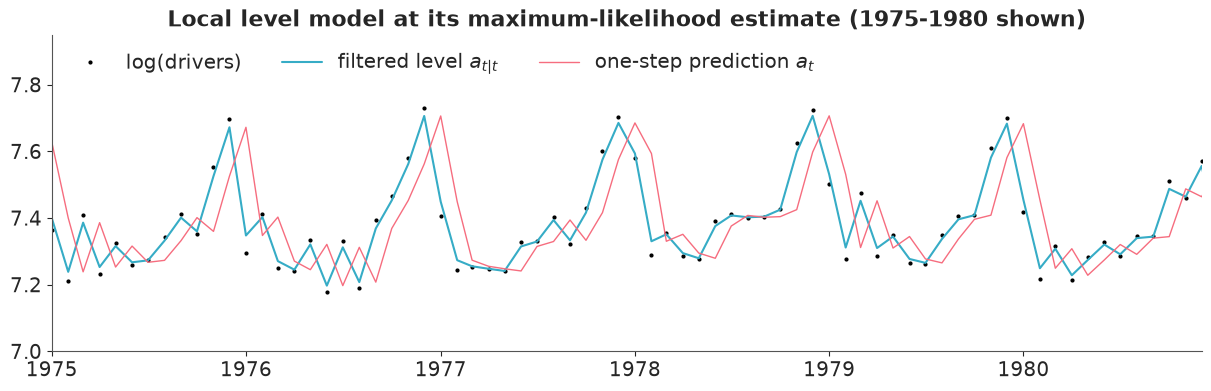

In [6]:
mle = optimize.minimize(
    lambda log_s: -local_level_filter(y_np, np.exp(log_s[0]), np.exp(log_s[1]), A1, P1)[0],
    x0=np.log([0.10, 0.03]),
)
s_eps_hat, s_eta_hat = np.exp(mle.x)
print(f"maximum likelihood: sigma_eps = {s_eps_hat:.3f}, sigma_eta = {s_eta_hat:.3f}, loglik = {-mle.fun:.1f}")

_, predicted_np, filtered_np = local_level_filter(y_np, s_eps_hat, s_eta_hat, A1, P1)

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(y_drivers.index, y_np, ".", color="k", ms=4, label="log(drivers)")
ax.plot(y_drivers.index, filtered_np, color="C0", label="filtered level $a_{t|t}$")
ax.plot(y_drivers.index, predicted_np, color="C1", lw=1, label="one-step prediction $a_t$")
ax.set(xlim=(pd.Timestamp("1975-01-01"), pd.Timestamp("1980-12-01")), ylim=(7.0, 7.95),
       title="Local level model at its maximum-likelihood estimate (1975-1980 shown)")
ax.legend(ncol=3, loc="upper left");

The filter works, and the picture shows why a local level on its own is the wrong model.
With no seasonal component, the only way to follow the December peaks is to make the level
very mobile: the estimated level innovation ($\sigma_\eta \approx 0.11$) is more than twice
the observation noise ($\sigma_\varepsilon \approx 0.05$), the "level" chases last month's
value, and the one-step predictions are simply the data shifted right by a month. The
seasonality has been absorbed into the wrong component. Section 3 fixes that.

First, the promised check that nothing is magic: `pymc_extras.statespace` should give the
same log-likelihood for the same model at the same parameter values.

In [7]:
ll_mod = (st.LevelTrend(name="level", order=1, innovations_order=1)
          + st.MeasurementError(name="obs")).build(name="local_level", verbose=False)

with pm.Model(coords=ll_mod.coords) as ll_model:
    pm.Deterministic("initial_level", pt.as_tensor([A1]), dims=ll_mod.param_dims["initial_level"])
    pm.Deterministic("P0", pt.as_tensor([[P1]]), dims=ll_mod.param_dims["P0"])
    pm.HalfNormal("sigma_level", 0.05, dims=ll_mod.param_dims["sigma_level"])
    pm.HalfNormal("sigma_obs", 0.1)
    ll_mod.build_statespace_graph(y_drivers)
    package_logp = ll_model.compile_logp(vars=[ll_model["obs"]])

at = {"sigma_level_log__": np.log([0.03]), "sigma_obs_log__": np.log(0.10)}
print(f"pymc_extras Kalman filter: {float(package_logp(at)):.3f}    NumPy, 10 lines: {loglik:.3f}")

pymc_extras Kalman filter: 93.929    NumPy, 10 lines: 93.929


They agree to three decimals (the package adds a tiny jitter to every covariance for
numerical safety, which accounts for the rest). The general filter is the same three steps
with matrices: a state **vector** $x_t$, a transition matrix $T$, a design matrix $Z_t$ that
picks out what is observed, and covariances $Q$ (state shocks) and $H$ (observation noise):

$$
y_t = Z_t x_t + \varepsilon_t,\quad \varepsilon_t \sim \text{N}(0, H), \qquad
x_{t+1} = T x_t + R\,\eta_t,\quad \eta_t \sim \text{N}(0, Q), \qquad x_1 \sim \text{N}(x_0, P_0).
$$

## 3 · A structural time-series model with `pymc_extras.statespace`

A **structural** model writes the series as a sum of interpretable pieces, each of which is a
small state-space model; stacking their state vectors gives one big one:

$$
\log(\text{drivers}_t) = \underbrace{\mu_t}_{\text{level}} + \underbrace{\gamma_t}_{\text{seasonal}}
+ \underbrace{\beta_p \log(\text{petrol}_t) + \beta_k \log(\text{kms}_t)}_{\text{explanatory}}
+ \underbrace{\lambda \cdot \text{law}_t}_{\text{intervention}} + \varepsilon_t
$$

- **Level**: the random walk of section 2. A stochastic slope could be added
  (`LevelTrend(order=2)`); a series with no persistent direction does not need one, and it is
  the first exercise at the end.
- **Seasonal**, "dummy" form: twelve monthly effects constrained to sum to zero over any
  year, up to a shock: $\gamma_t = -\sum_{j=1}^{11} \gamma_{t-j} + \omega_t$. With
  $\sigma_\omega = 0$ it is a fixed monthly pattern; with $\sigma_\omega > 0$ the pattern
  evolves. The state holds the last 11 effects. The alternative **trigonometric** form
  (`FrequencySeasonality`) writes the pattern as a sum of up to six harmonics; its advantage
  is that you may keep only the first few when the seasonal shape is smooth or the period is
  long (weekly data with a yearly cycle). For monthly data the full dummy form is cheap.
- **Regression and intervention**: a coefficient is a state that *never moves* (zero
  innovation variance) and a design matrix $Z_t$ that contains the regressor. The law enters as
  a step dummy, i.e. a **permanent level shift** $\lambda$ from February 1983. That is the
  right shape for a law with immediate, near-universal compliance (belt wearing went from
  about 40% to over 90% within the month). A gradual effect would use a ramp or a decaying
  pulse as the regressor instead; the shape is an assumption you choose, not something the
  model discovers.
- **Measurement error** $\varepsilon_t$: the irregular month-to-month noise.

Components are combined with `+` and compiled into one model with `.build()`, which prints
what it expects **you** to supply:

In [8]:
structural = (
    st.LevelTrend(name="level", order=1, innovations_order=1)
    + st.TimeSeasonality(name="seasonal", season_length=12, innovations=True)
    + st.Regression(name="exog", state_names=list(exog.columns))
    + st.MeasurementError(name="obs")
)
ss_mod = structural.build(name="seatbelts")

                               Model Requirements                                
                                                                                 
  Variable          Shape       Constraints                          Dimensions  
 ─────────────────────────────────────────────────────────────────────────────── 
  initial_level     (1,)                                       ('state_level',)  
  sigma_level       (1,)        Positive                       ('shock_level',)  
  params_seasonal   (11,)                                   ('state_seasonal',)  
  sigma_seasonal    ()          Positive                                   None  
  beta_exog         (3,)                                        ('state_exog',)  
  sigma_obs         ()          Positive                                   None  
  P0                (15, 15)    Positive semi-definite   ('state', 'state_aux')  
                                                                                 
  data_exog         (None, 3)   pm.Data                  ('time', 'state_exog')  
                                                                                 
   These parameters should be assigned priors inside a PyMC model block before   
                   calling the build_statespace_graph method.                    

In [9]:
print("states     :", ss_mod.state_names)
print("parameters :", ss_mod.param_names)
print("param dims :", ss_mod.param_dims)
print("data       :", ss_mod.data_info)

trig = (st.LevelTrend(name="level", order=1, innovations_order=1)
        + st.FrequencySeasonality(name="seasonal", season_length=12, n=2, innovations=True)
        + st.MeasurementError(name="obs")).build(verbose=False)
print("\ntrigonometric seasonal with n=2 harmonics, states:", trig.state_names)

states     : ('level', 'seasonal_1', 'seasonal_2', 'seasonal_3', 'seasonal_4', 'seasonal_5', 'seasonal_6', 'seasonal_7', 'seasonal_8', 'seasonal_9', 'seasonal_10', 'seasonal_11', 'log_petrol', 'log_kms', 'law')
parameters : ('initial_level', 'sigma_level', 'params_seasonal', 'sigma_seasonal', 'beta_exog', 'sigma_obs', 'P0')
param dims : {'initial_level': ('state_level',), 'sigma_level': ('shock_level',), 'params_seasonal': ('state_seasonal',), 'beta_exog': ('state_exog',), 'P0': ('state', 'state_aux')}
data       : {'data_exog': {'shape': (None, 3), 'dims': ('time', 'state_exog'), 'exogenous': True}}

trigonometric seasonal with n=2 harmonics, states: ('level', 'Cos_0_seasonal', 'Sin_0_seasonal', 'Cos_1_seasonal', 'Sin_1_seasonal')


How the package works, in one paragraph. `build()` creates the symbolic matrices
$x_0, P_0, T, Z, R, H, Q$ with **placeholders** for the parameters in the table. Inside a
`pm.Model` you create a variable *with exactly that name* (and, ideally, the listed `dims`;
`ss_mod.coords` supplies the coordinates) for every row, and register the regressors as
`pm.Data("data_exog", ...)` with dims `("time", "state_exog")`. Then
`ss_mod.build_statespace_graph(y)` substitutes your variables into the matrices, runs the
Kalman filter as a `pytensor.scan`, and registers the resulting log-likelihood as the
observed variable `obs`. A missing or extra name is an error, which is a good thing.

### Priors, on the log scale

All three standard deviations are in log units, so 0.01 means "about 1%":

- `sigma_obs ~ HalfNormal(0.1)`: irregular noise of a few percent up to 20% a month.
- `sigma_level ~ HalfNormal(0.05)`: the underlying level moves by at most a few percent a
  month. A level that moved 10% a month would be doing the seasonal component's job, as in
  section 2.
- `sigma_seasonal ~ HalfNormal(0.02)`: the seasonal *pattern* changes slowly if at all.

### Where do the coefficients go? Two ways to declare the initial state

The state at the first time point is $x_1 \sim \text{N}(x_0, P_0)$, and $x_0$ is made of the
parameters `initial_level`, `params_seasonal` and `beta_exog`. The package documentation's
pattern is to give each of those a prior and set `P0` to something small: NUTS then samples
1 + 11 + 3 = 15 location parameters plus the three standard deviations.

But a Normal prior on $x_0$ with $P_0 = 0$ is *the same model* as a fixed $x_0$ at the prior
mean with **the prior variance in `P0`** - and in that form the Kalman filter integrates the
initial level, the seasonal pattern and the regression coefficients out analytically along
with everything else. They are Gaussian and enter linearly, so there is no reason to make
NUTS do it. We use that form: `Deterministic` constants for the means, prior variances on the
diagonal of `P0`, and **three** sampled parameters. (When this notebook was developed the
documentation's form gave the same posterior and took roughly three times as long, because
18 parameters need longer NUTS trajectories and every gradient is a full pass of the filter.)
The coefficients come back from the smoother in section 5.

The implied priors: initial level `Normal(log 1500, 0.5)`, monthly effects `Normal(0, 0.2)`,
`Normal(0, 1)` for the two elasticities, and for the law effect a first guess of
`Normal(0, 1)` - "wide and centred on no effect" - which the prior predictive check below
will make us reconsider.

In [10]:
def make_model(y, level_prior_mean, law_prior_sd):
    """The structural model for one log-series. Only the three standard deviations are sampled."""
    # prior sd of the initial state: level, 11 seasonal effects, 2 elasticities, law effect
    prior_sd_x0 = np.r_[0.5, np.full(11, 0.2), 1.0, 1.0, law_prior_sd]
    with pm.Model(coords=ss_mod.coords) as model:
        model.add_coord("time", y.index)
        pm.Data("data_exog", exog.loc[y.index].to_numpy(), dims=("time", "state_exog"))

        # x0: prior means as constants ...
        pm.Deterministic("initial_level", pt.as_tensor([level_prior_mean]),
                         dims=ss_mod.param_dims["initial_level"])
        pm.Deterministic("params_seasonal", pt.zeros(11), dims=ss_mod.param_dims["params_seasonal"])
        pm.Deterministic("beta_exog", pt.zeros(3), dims=ss_mod.param_dims["beta_exog"])
        # ... P0: prior variances. The Kalman filter integrates these 15 quantities out.
        pm.Deterministic("P0", pt.as_tensor(np.diag(prior_sd_x0**2)), dims=ss_mod.param_dims["P0"])

        pm.HalfNormal("sigma_level", 0.05, dims=ss_mod.param_dims["sigma_level"])
        pm.HalfNormal("sigma_seasonal", 0.02)
        pm.HalfNormal("sigma_obs", 0.1)

        ss_mod.build_statespace_graph(y)
    return model


SIGMAS = ["sigma_level", "sigma_seasonal", "sigma_obs"]

(`Deterministic` rather than `pm.Data` for the constants: the post-estimation methods look
every parameter up in the posterior group, and fail with "Cannot sample from flat variable"
if it is not there.)

### Prior predictive check

`pm.sample_prior_predictive` draws the parameters; `sample_unconditional_prior` then simulates
whole trajectories from the state-space dynamics, using the real regressors.

Sampling: [obs, sigma_level, sigma_obs, sigma_seasonal]


Sampling: [prior_combined]


Sampling: [obs, sigma_level, sigma_obs, sigma_seasonal]


law prior sd 1.0: share of simulated series whose year after the law differs from the year before by more than a factor 2: 0.51;  simulated months outside 100-25,000 drivers: 0.010


Sampling: [prior_combined]


law prior sd 0.3: share of simulated series whose year after the law differs from the year before by more than a factor 2: 0.04;  simulated months outside 100-25,000 drivers: 0.005


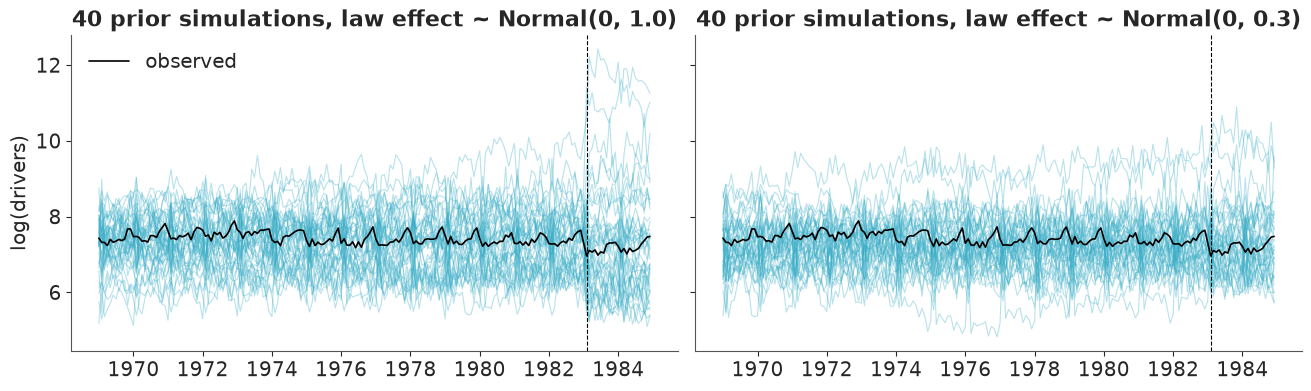

In [11]:
def simulate_prior(law_prior_sd, n_sim=200):
    prior_model = make_model(y_drivers, np.log(1500.0), law_prior_sd)
    with prior_model:
        prior = pm.sample_prior_predictive(n_sim, random_seed=RANDOM_SEED)
    sims = ss_mod.sample_unconditional_prior(prior, random_seed=RANDOM_SEED)
    return sims["prior_observed"].isel(chain=0, observed_state=0).values          # (n_sim, time)


before = (belts.index >= "1982-02-01") & (belts.index < LAW_START)
after = (belts.index >= LAW_START) & (belts.index < "1984-02-01")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, law_sd in zip(axes, [1.0, 0.3]):
    sims = simulate_prior(law_sd)
    ax.plot(y_drivers.index, sims[:40].T, color="C0", alpha=0.35, lw=0.8)
    ax.plot(y_drivers.index, y_np, color="k", lw=1.2, label="observed")
    ax.axvline(LAW_START, color="k", ls="--", lw=0.8)
    ax.set(title=f"40 prior simulations, law effect ~ Normal(0, {law_sd})")
    jump = sims[:, after].mean(axis=1) - sims[:, before].mean(axis=1)
    print(f"law prior sd {law_sd}: share of simulated series whose year after the law differs from the "
          f"year before by more than a factor 2: {np.mean(np.abs(jump) > np.log(2)):.2f};  "
          f"simulated months outside 100-25,000 drivers: "
          f"{np.mean((sims < np.log(100)) | (sims > np.log(25000))):.3f}")
axes[0].set(ylabel="log(drivers)")
axes[0].legend(loc="upper left");
del sims

The left panel is what the check is for. Everything looks like a plausible casualty series
until February 1983, where the fan bursts open: with `Normal(0, 1)` on $\lambda$ about half of
the simulated series change by more than a factor of two in the year after the law. No
road-safety measure does that; "wide and centred on zero" was wide on a scale nobody had
looked at. `Normal(0, 0.3)` puts two prior standard deviations at -45% / +82%, still generous
for a seat belt, and brings the factor-two share down to a few percent (right panel).

What remains wide is the long-run spread: a random walk's variance accumulates over 192
months, and a unit elasticity on a distance index that doubled is allowed. That is
acceptable - the month-to-month behaviour, the seasonal amplitudes and the noise level are what
these priors need to get roughly right, and they do; about 1% of simulated months or fewer
fall outside 100-25,000 drivers.

In [12]:
LAW_PRIOR_SD = 0.3
model = make_model(y_drivers, np.log(1500.0), LAW_PRIOR_SD)
model

## 4 · Fit, and diagnose

Three parameters adapt quickly, so 500 warm-up steps are plenty (under nutpie the default is
only 400 anyway); `target_accept=0.9` because `sigma_seasonal` has posterior mass close to
zero, where the log-transformed parameter has a long flat tail and the default step size
produced the odd divergence.

In [13]:
def fit(model, tune=500, draws=1000):
    start = time.perf_counter()
    with model:
        idata = pm.sample(tune=tune, draws=draws, target_accept=0.9, random_seed=RANDOM_SEED)
    return idata, time.perf_counter() - start


idata, wall_kalman = fit(model)
print(f"pm.sample wall-clock, compilation included: {wall_kalman:.0f} s")

NUTS[nutpie]: [sigma_level, sigma_seasonal, sigma_obs]


pm.sample wall-clock, compilation included: 43 s


In [14]:
print("divergences:", int(idata.sample_stats["diverging"].sum()))
az.summary(idata, var_names=SIGMAS, ci_kind="hdi", ci_prob=0.94, round_to=4)

divergences: 0


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_level[level],0.0183,0.0053,0.0093,0.0284,2088.9352,2460.8522,1.0029,0.0001,0.0001
sigma_seasonal,0.0041,0.0031,0.0000,0.0097,1400.1192,1130.2098,1.0030,0.0001,0.0000
sigma_obs,0.0624,0.0046,0.0538,0.0711,2291.5025,1924.1709,1.0027,0.0001,0.0001


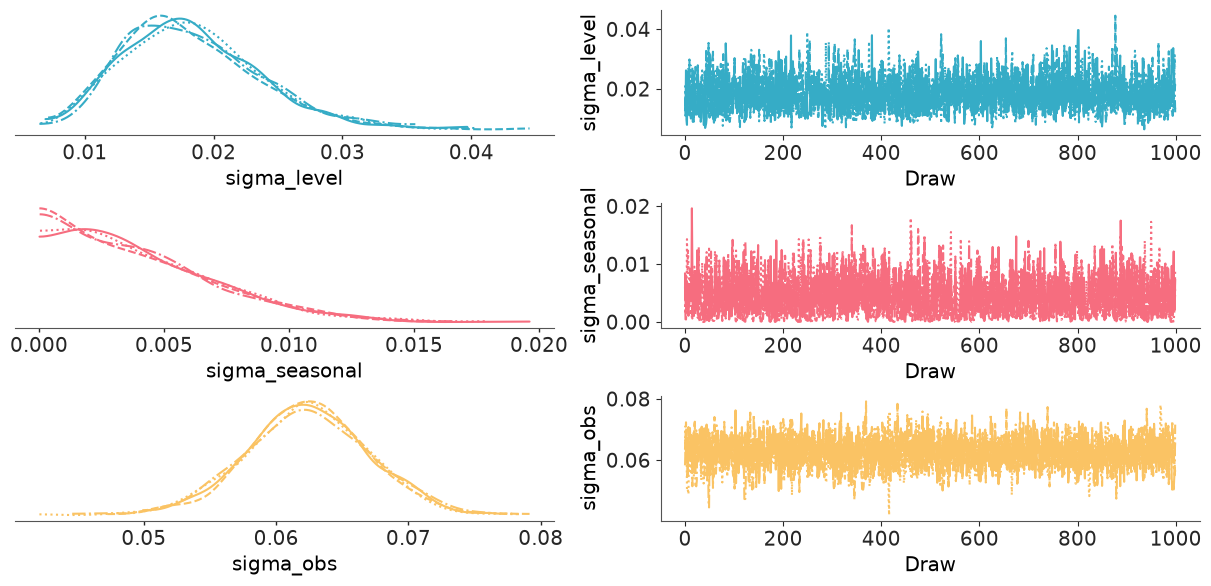

In [15]:
az.plot_trace_dist(idata, var_names=SIGMAS);

Clean: no divergences, `r_hat` of 1.00, ESS in the thousands from 4 x 1000 draws - what you
expect from a three-dimensional posterior. Reading the numbers:

- `sigma_obs` of about 0.06: the irregular component is about 6% of the monthly total. That
  is close to what Poisson counting noise alone would give for counts of this size only if
  they were around 250; at 1,700 a month Poisson noise is 2.4%, so most of the irregular is
  real month-to-month variation (weather, holidays falling differently, ...).
- `sigma_level` of about 0.02, a sixth of the value the seasonal-free model of section 2
  needed: the level is now a slowly moving thing.
- `sigma_seasonal` is small, with a posterior piled up against zero: the data cannot
  distinguish a slowly evolving seasonal pattern from a fixed one. (Harvey and Durbin used a
  fixed one.) The model is free to choose, and it costs nothing to let it.

## 5 · Recover the states: the Kalman smoother

The posterior so far contains three standard deviations and no level, no seasonal pattern and
no law effect. They were integrated out, not lost: given the parameters, the distribution of
all states given **all** the data is Gaussian and the **Kalman smoother** computes it (a
backward pass after the forward filter). `sample_conditional_posterior` does that for every
posterior draw and samples one whole state trajectory from each - a joint draw, so
cross-time correlations are right (that is the *simulation smoother*).

Memory matters here: the outputs are (draws x time x states) arrays for the predicted,
filtered and smoothed states, and if you ask `sample_filter_outputs` for smoothed
*covariances* you get (draws x time x states x states) - a third of a gigabyte for 1000 draws
of this small model. So: **thin first** (every 4th draw: 1000 trajectories), keep what you
plot, delete the rest.

In [16]:
STATE_NAMES = list(ss_mod.state_names)


def smooth(idata, every):
    """Joint posterior draws of the states: (sample, time, state) plus the noisy smoothed observations."""
    thin = idata.isel(draw=slice(None, None, every))
    post = ss_mod.sample_conditional_posterior(thin, random_seed=RANDOM_SEED)
    states = post["smoothed_posterior"].stack(sample=("chain", "draw")).transpose("sample", "time", "state")
    y_rep = post["smoothed_posterior_observed"].isel(observed_state=0).stack(sample=("chain", "draw"))
    return states.values, y_rep.transpose("sample", "time").values


def components(states, x):
    """Split state draws into the additive pieces of the model. x: regressors, (time, 3)."""
    level = states[:, :, STATE_NAMES.index("level")]
    seasonal = states[:, :, STATE_NAMES.index("seasonal_1")]          # first seasonal state = current month
    beta = states[:, -1, [STATE_NAMES.index(c) for c in exog.columns]]  # constant states: any time will do
    return level, seasonal, beta, beta[:, None, :] * x[None, :, :]


states, _ = smooth(idata, every=4)
level, seasonal, beta, contrib = components(states, exog.to_numpy())
print("state draws:", states.shape, f"({states.nbytes / 1e6:.0f} MB)")
print("a coefficient state is constant over time: max sd over time of the law state =",
      f"{states[:, :, STATE_NAMES.index('law')].std(axis=1).max():.1e}")
del states

coef = pd.DataFrame(beta, columns=exog.columns)
coef.describe(percentiles=[0.03, 0.5, 0.97]).T[["mean", "std", "3%", "50%", "97%"]].round(3)

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


state draws: (1000, 192, 15) (23 MB)
a coefficient state is constant over time: max sd over time of the law state = 7.2e-06


,mean,std,3%,50%,97%
log_petrol,-0.271,0.108,-0.472,-0.274,-0.064
log_kms,0.041,0.110,-0.162,0.043,0.242
law,-0.232,0.047,-0.321,-0.232,-0.150


The coefficients are back, with full posteriors, although NUTS never saw them. The petrol-price
elasticity is negative as expected (dearer petrol, less and slower driving, fewer casualties).
The distance elasticity is poorly determined - `kms` is smooth and trending, so it competes with
the level for the same slow movements, and the level wins. The law effect is about -0.23 with a
standard deviation of 0.05: section 9 turns it into the answer. First, is the sampler
comparison as one-sided as the introduction implied?

## 6 · The brute-force contrast, measured

The *same model* - same priors, same data - written the C07 way: every latent shock is a
parameter. The level is a cumulative sum of 191 scaled standard-Normal steps (a non-centred
random walk). The seasonal recursion $\gamma_t = -\sum_j \gamma_{t-j} + \sigma_\omega\omega_t$ is
linear, so it can be unrolled once in NumPy into two fixed matrices,
$\gamma = A\,\gamma_{\text{init}} + \sigma_\omega B\,\omega$, which keeps `scan` out of the
brute-force model altogether. NUTS gets 3 standard deviations + 3 coefficients + 1 initial
level + 11 initial seasonal effects + 191 + 191 shocks = **400 parameters**. The latent
shocks are not needed for the comparison, so they are dropped as soon as the summary is made.

In [17]:
n = len(y_np)
A = np.zeros((n, 11))            # gamma_t as a linear function of the 11 initial effects ...
B = np.zeros((n, n - 1))         # ... and of the n-1 seasonal shocks
A[0, 0] = 1.0
last_A, last_B = list(np.eye(11)), [np.zeros(n - 1) for _ in range(11)]   # most recent 11 effects
for t in range(1, n):
    a_new, b_new = -np.sum(last_A, axis=0), -np.sum(last_B, axis=0)
    b_new[t - 1] += 1.0
    A[t], B[t] = a_new, b_new
    last_A, last_B = [a_new, *last_A[:-1]], [b_new, *last_B[:-1]]

with pm.Model(coords={"time": y_drivers.index, "exog": list(exog.columns)}) as brute:
    sigma_level = pm.HalfNormal("sigma_level", 0.05)
    sigma_seasonal = pm.HalfNormal("sigma_seasonal", 0.02)
    sigma_obs = pm.HalfNormal("sigma_obs", 0.1)
    beta_bf = pm.Normal("beta", 0, [1.0, 1.0, LAW_PRIOR_SD], dims="exog")
    level_1 = pm.Normal("level_1", np.log(1500.0), 0.5)
    gamma_init = pm.Normal("gamma_init", 0, 0.2, shape=11)
    eta = pm.Normal("eta", 0, 1, shape=n - 1)
    omega = pm.Normal("omega", 0, 1, shape=n - 1)

    level_bf = level_1 + pt.concatenate([[0.0], pt.cumsum(sigma_level * eta)])
    seasonal_bf = pt.dot(A, gamma_init) + sigma_seasonal * pt.dot(B, omega)
    pm.Normal("y", level_bf + seasonal_bf + pt.dot(exog.to_numpy(), beta_bf), sigma_obs,
              observed=y_np, dims="time")

    start = time.perf_counter()
    idata_bf = pm.sample(tune=1000, draws=1000, target_accept=0.9, random_seed=RANDOM_SEED)
    wall_brute = time.perf_counter() - start

NUTS[nutpie]: [sigma_level, sigma_seasonal, sigma_obs, beta, level_1, gamma_init, eta, omega]


In [18]:
def sampler_row(idata, wall, n_params):
    ess = az.ess(idata, var_names=SIGMAS)
    min_ess = min(float(ess[v].min()) for v in SIGMAS)
    stats_ = idata.sample_stats
    return {
        "NUTS parameters": n_params,
        "wall-clock (s)": round(wall, 1),
        "divergences": int(stats_["diverging"].sum()),
        "gradient evaluations per draw": round(float(stats_["n_steps"].mean()), 1),
        "min bulk ESS (sigmas)": round(min_ess),
        "ESS per second": round(min_ess / wall, 1),
    }


comparison = pd.DataFrame({
    "Kalman filter (pymc_extras)": sampler_row(idata, wall_kalman, 3),
    "brute force (latent shocks)": sampler_row(idata_bf, wall_brute, 400),
}).T
comparison

,NUTS parameters,wall-clock (s),divergences,gradient evaluations per draw,min bulk ESS (sigmas),ESS per second
Kalman filter (pymc_extras),3.0,42.9,0.0,6.1,1400.0,32.6
brute force (latent shocks),400.0,5.4,85.0,123.1,660.0,121.6


In [19]:
def mean_sd(x):
    return f"{float(np.mean(x)):.4f} ± {float(np.std(x)):.4f}"


post_bf = idata_bf.posterior
agreement = pd.DataFrame({
    "Kalman filter": {**{v: mean_sd(idata.posterior[v]) for v in SIGMAS},
                      "law effect": mean_sd(coef["law"]), "petrol elasticity": mean_sd(coef["log_petrol"])},
    "brute force": {**{v: mean_sd(post_bf[v]) for v in SIGMAS},
                    "law effect": mean_sd(post_bf["beta"].sel(exog="law")),
                    "petrol elasticity": mean_sd(post_bf["beta"].sel(exog="log_petrol"))},
})

div_bf = idata_bf.sample_stats["diverging"]
if int(div_bf.sum()) > 0:
    print(f"brute force: median sigma_seasonal at divergent draws "
          f"{float(post_bf['sigma_seasonal'].where(div_bf).median()):.4f}, over all draws "
          f"{float(post_bf['sigma_seasonal'].median()):.4f}")
del idata_bf, post_bf
agreement

brute force: median sigma_seasonal at divergent draws 0.0039, over all draws 0.0036


,Kalman filter,brute force
sigma_level,0.0183 ± 0.0053,0.0179 ± 0.0048
sigma_seasonal,0.0041 ± 0.0031,0.0042 ± 0.0031
sigma_obs,0.0624 ± 0.0046,0.0627 ± 0.0045
law effect,-0.2322 ± 0.0469,-0.2325 ± 0.0487
petrol elasticity,-0.2705 ± 0.1084,-0.2703 ± 0.1043


Read this honestly, because it is not the rout the introduction may have led you to expect.

- **The posteriors agree** to within Monte Carlo error, for the variances and for the
  coefficients - which one method sampled and the other integrated out and recovered with the
  smoother. Same model, two ways of doing the same integral.
- **On raw speed, brute force wins here**: several times less wall-clock and three to four
  times the effective samples per second (the exact ratio moves with the machine's load). At
  $T = 192$ the brute-force log-density is a cumulative sum and two matrix-vector products,
  microseconds of vectorised arithmetic. Each Kalman gradient is a 192-step *sequential*
  `scan` through 15 x 15 matrix algebra, differentiated, and the graph takes a while to compile.
  The Kalman model needs about 6 gradient evaluations per draw against about 120 and gets
  twice the ESS from the same number of draws - the geometry is far better - but each of its
  gradients costs on the order of a hundred times more.
- **On reliability, the Kalman version wins**: zero divergences against dozens at the same
  `target_accept`. The brute-force posterior is a 400-dimensional hierarchy in which the
  shocks and their scales are entangled - the geometry C07 is about. The divergent draws are
  not confined to the neck of a funnel near `sigma_seasonal = 0` (their median is about the
  same as the overall one), so there is no single cheap fix; the answers happen to agree here,
  but with brute force you have to *earn* that trust by raising `target_accept`,
  reparameterising and checking where the divergences sit, and every fix eats into the speed
  advantage.

So for a series this short the honest summary is: the Kalman filter buys **clean geometry,
exact state inference and the machinery of sections 8-10 - not speed**. The balance shifts as
series get longer (the filter's cost is linear in $T$ and it still has three parameters;
brute force adds two parameters per time step to an already awkward posterior), but this
notebook has not measured where the lines cross, so it will not tell you.

## 7 · The decomposition

The reason to fit a *structural* model: every piece has a meaning and a credible band. The
bands below are 94% intervals over the 1000 joint smoother draws, so they include parameter
uncertainty as well as state uncertainty.

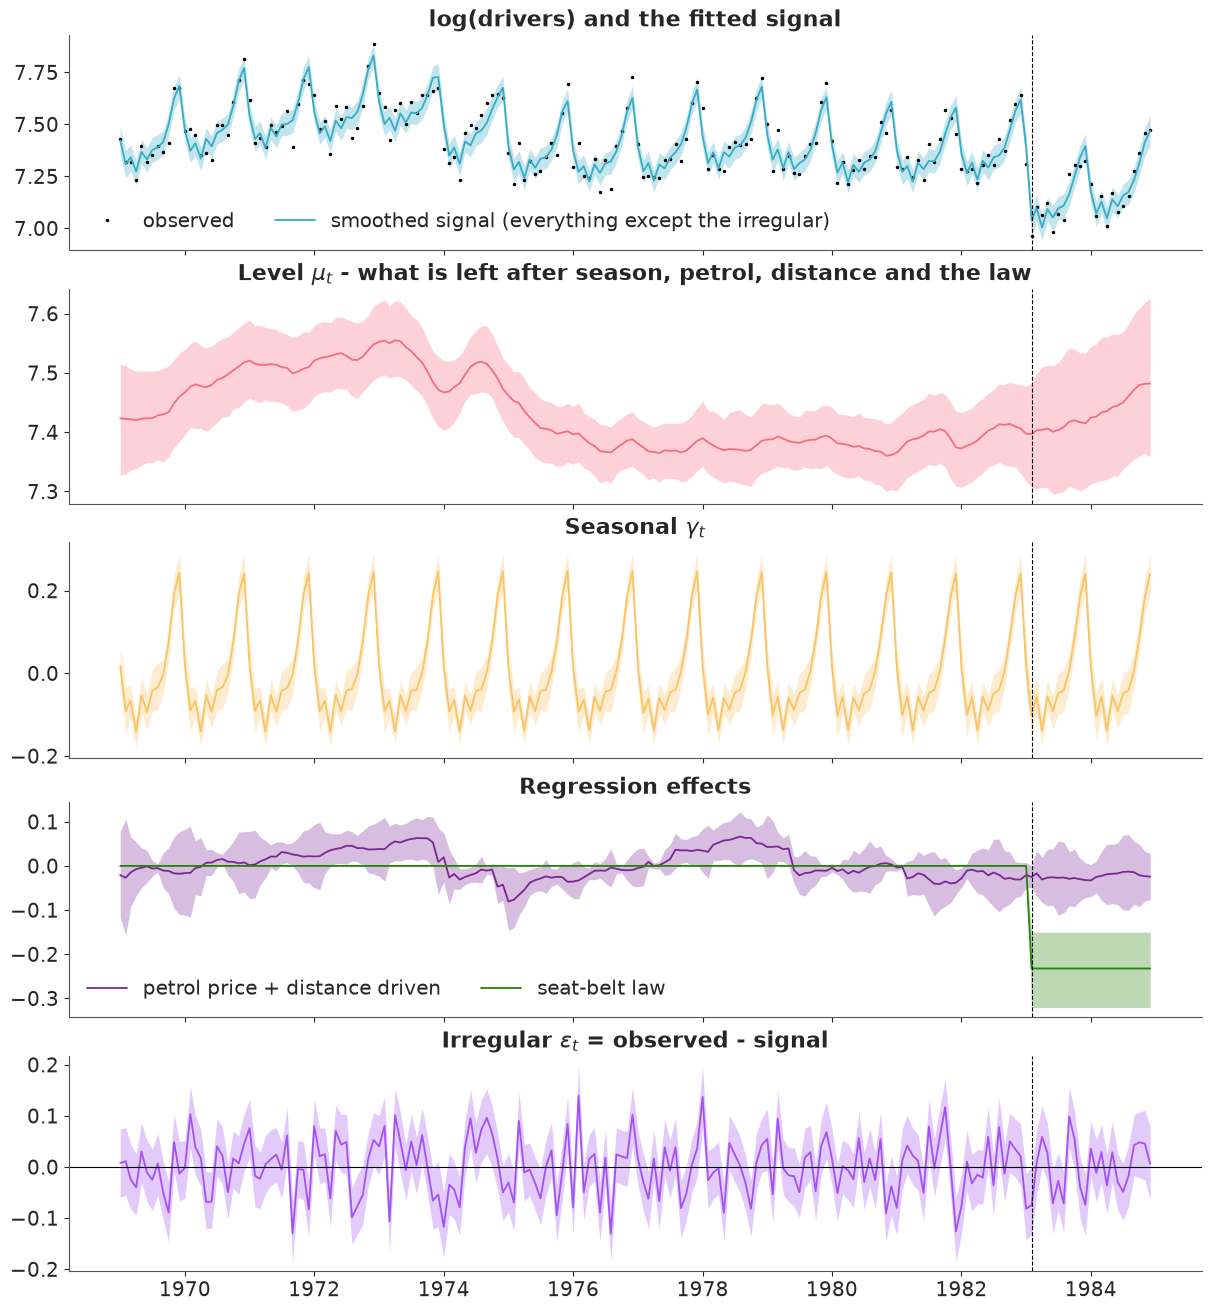

In [20]:
def band(ax, draws, color, label=None):
    lo, mid, hi = np.quantile(draws, [0.03, 0.5, 0.97], axis=0)
    ax.fill_between(y_drivers.index, lo, hi, color=color, alpha=0.3, lw=0)
    ax.plot(y_drivers.index, mid, color=color, lw=1.3, label=label)


signal = level + seasonal + contrib.sum(axis=2)
irregular = y_np[None, :] - signal

fig, axes = plt.subplots(5, 1, figsize=(12, 13), sharex=True)
axes[0].plot(y_drivers.index, y_np, ".", color="k", ms=3, label="observed")
band(axes[0], signal, "C0", "smoothed signal (everything except the irregular)")
axes[0].set(title="log(drivers) and the fitted signal")
axes[0].legend(loc="lower left", ncol=2)

band(axes[1], level, "C1")
axes[1].set(title="Level $\\mu_t$ - what is left after season, petrol, distance and the law")

band(axes[2], seasonal, "C2")
axes[2].set(title="Seasonal $\\gamma_t$")

band(axes[3], contrib[:, :, 0] + contrib[:, :, 1], "C3", "petrol price + distance driven")
band(axes[3], contrib[:, :, 2], "C4", "seat-belt law")
axes[3].set(title="Regression effects")
axes[3].legend(loc="lower left", ncol=2)

band(axes[4], irregular, "C5")
axes[4].axhline(0, color="k", lw=0.8)
axes[4].set(title="Irregular $\\varepsilon_t$ = observed - signal")
for ax in axes:
    ax.axvline(LAW_START, color="k", ls="--", lw=0.8)

In [21]:
month_effect = pd.DataFrame(seasonal.mean(axis=0), index=y_drivers.index, columns=["effect"])
by_month = month_effect.groupby(month_effect.index.month).effect.mean()
print("average seasonal effect by calendar month, as % of the level:")
print((100 * (np.exp(by_month) - 1)).round(1).to_string())
print(f"\nlevel, Jan 1983 -> Dec 1984 (posterior median): {np.median(level[:, -24]):.3f} -> "
      f"{np.median(level[:, -1]):.3f}")
print(f"posterior correlation between the law effect and the final level: "
      f"{np.corrcoef(beta[:, 2], level[:, -1])[0, 1]:.2f}")
print(f"average 94% band width: level {np.mean(np.diff(np.quantile(level, [0.03, 0.97], axis=0), axis=0)):.3f}, "
      f"seasonal {np.mean(np.diff(np.quantile(seasonal, [0.03, 0.97], axis=0), axis=0)):.3f}")

average seasonal effect by calendar month, as % of the level:
time
1      1.6
2     -9.2
3     -6.0
4    -13.0
5     -5.4
6     -8.7
7     -4.4
8     -3.8
9      0.1
10     8.3
11    20.7
12    27.7

level, Jan 1983 -> Dec 1984 (posterior median): 7.397 -> 7.482
posterior correlation between the law effect and the final level: -0.74
average 94% band width: level 0.131, seasonal 0.085


- **Level.** Rises to about 7.55 in 1973, falls by some 15% through 1974-75 (the oil crisis
  and its aftermath - over and above what the petrol-price regressor explains), then sits
  near 7.38 for eight years. Its 94% band is about 0.13 wide: the level is known to roughly
  ±6%.
- **Seasonal.** November is about 21% and December 28% above the level, April 13% below; the
  pattern is essentially the same in every year, which is what `sigma_seasonal` near zero
  means.
- **Regression effects.** Petrol price and distance together move the series by less than
  ±0.1; the visible step down at the start of 1974 is the petrol-price shock. The law is a
  step of about -0.23 with a band from -0.32 to -0.15.
- **Irregular.** Mostly within ±0.1, no visible pattern - but see the next section for why
  this panel is not a model check.

One feature deserves a second look: **after the law the level band fans out and its median
drifts up** by about 0.09. Level and law effect are competing explanations for the last 23
months - "a big drop from the law, partly offset by a rising level" fits about as well as "a
smaller drop and a flat level" - and the posterior correlation between $\lambda$ and the final
level is about -0.7. The uncertainty in $\lambda$ already includes this. What separates them
at all is the **smoothness of the level**: with monthly steps of about 0.018, a fall of 0.23
in a single month is a thirteen-sigma event for the random walk, so the model assigns the
February 1983 drop to the law. That smoothness is the identifying assumption of the whole
analysis, exactly as "parallel trends" is for a difference-in-differences.

## 8 · The check that matters: one-step-ahead innovations

The smoothed signal above follows the data closely - of course it does, the smoother has seen
the future, and a flexible enough level will "fit" anything. Residuals from a smoothed fit are
the time-series version of checking a model on its training data.

The honest check uses the quantity from step 1 of the filter: the **innovation**
$v_t = y_t - \text{E}[y_t \mid y_{1:t-1}]$, the error of a genuine one-month-ahead forecast
made without seeing $y_t$. If the model is right, the standardised innovations
$v_t / \sqrt{F_t}$ are independent standard Normals - no autocorrelation (especially not at
lags 1 and 12), no fat tails. `sample_filter_outputs` returns the filter's predictive means and
variances; we ask for exactly those two outputs and nothing with a states-squared dimension.

The first 15 months are dropped: the filter starts from the vague prior in `P0` and needs as
many observations as there are states before its predictions mean anything.

In [22]:
filt = ss_mod.sample_filter_outputs(
    idata.isel(draw=slice(None, None, 4)),
    filter_output_names=["predicted_observed_states", "predicted_observed_covariances"],
    random_seed=RANDOM_SEED,
).posterior_predictive
pred_mean = filt["predicted_observed_states"].isel(observed_state=0).values          # (chain, draw, time)
pred_var = filt["predicted_observed_covariances"].isel(observed_state=0, observed_state_aux=0).values

BURN = 15
z_draws = ((y_np - pred_mean) / np.sqrt(pred_var))[:, :, BURN:]
z = z_draws.mean(axis=(0, 1))                         # posterior-mean standardised innovation
z_time = y_drivers.index[BURN:]
del filt


def acf(x, max_lag):
    x = x - x.mean()
    return np.array([np.dot(x[:-k], x[k:]) for k in range(1, max_lag + 1)]) / np.dot(x, x)


r = acf(z, 24)
ljung_box = len(z) * (len(z) + 2) * np.sum(r**2 / (len(z) - np.arange(1, 25)))
print(f"standardised innovations: mean {z.mean():.2f}, sd {z.std():.2f}, "
      f"skewness {stats.skew(z):.2f}, excess kurtosis {stats.kurtosis(z):.2f}")
print(f"ACF lag 1: {r[0]:.2f}, lag 12: {r[11]:.2f};  Ljung-Box Q(24) = {ljung_box:.1f}, "
      f"p = {stats.chi2.sf(ljung_box, 24):.2f}")
print(f"Shapiro-Wilk p = {stats.shapiro(z).pvalue:.2f};  |z| > 2 in {np.mean(np.abs(z) > 2):.1%} of months "
      f"(Normal: 4.6%)")
print(f"innovation in {LAW_START:%b %Y}, the first month under the law: "
      f"{z[list(z_time).index(LAW_START)]:+.2f}")
print("largest:", ", ".join(f"{t:%b %Y} ({v:+.1f})" for t, v in
                           sorted(zip(z_time, z), key=lambda p: -abs(p[1]))[:3]))

Sampling: []


standardised innovations: mean 0.03, sd 0.98, skewness -0.16, excess kurtosis -0.39
ACF lag 1: 0.06, lag 12: 0.04;  Ljung-Box Q(24) = 33.0, p = 0.10
Shapiro-Wilk p = 0.59;  |z| > 2 in 2.8% of months (Normal: 4.6%)
innovation in Feb 1983, the first month under the law: -1.04
largest: Dec 1981 (-2.8), Jun 1974 (+2.4), Sep 1983 (+2.2)


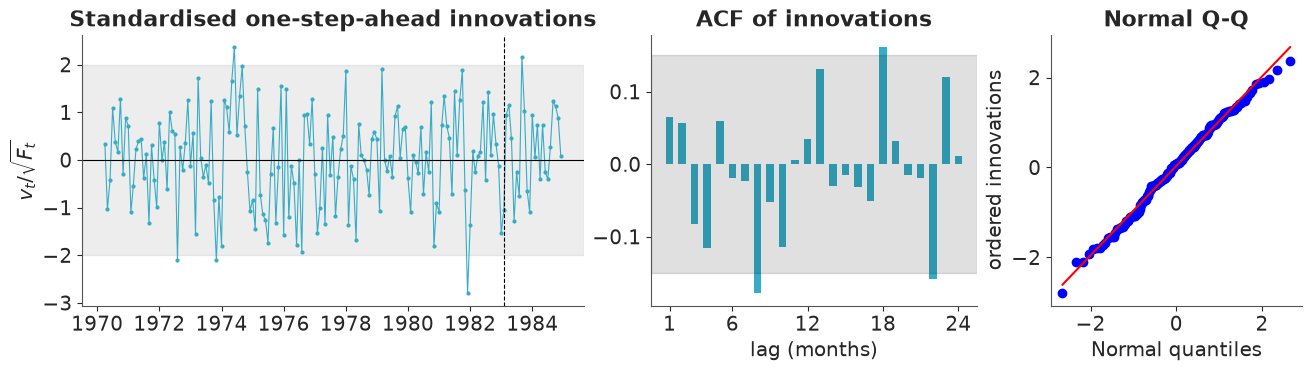

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), width_ratios=[2, 1.3, 1])
axes[0].plot(z_time, z, lw=0.8, marker=".", ms=4)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].axhspan(-2, 2, color="k", alpha=0.07)
axes[0].axvline(LAW_START, color="k", ls="--", lw=0.8)
axes[0].set(title="Standardised one-step-ahead innovations", ylabel="$v_t / \\sqrt{F_t}$")

axes[1].bar(np.arange(1, 25), r, width=0.6)
axes[1].axhspan(-2 / np.sqrt(len(z)), 2 / np.sqrt(len(z)), color="k", alpha=0.12)
axes[1].set(title="ACF of innovations", xlabel="lag (months)", xticks=[1, 6, 12, 18, 24])

stats.probplot(z, dist="norm", plot=axes[2])
axes[2].set(title="Normal Q-Q", xlabel="Normal quantiles", ylabel="ordered innovations");

Nothing to fix. The standardised innovations have mean 0.03 and standard deviation 0.98; the
autocorrelations at lags 1 and 12 - where a missing dynamic or a wrong seasonal would show up -
are 0.06 and 0.04; three of 24 lags (8, 18 and 22) touch the ±2/√n band with no pattern, and
the Ljung-Box test over 24 lags gives p = 0.10. The Q-Q plot is straight, Shapiro-Wilk does
not reject, and fewer months than expected lie beyond ±2. The largest surprise is December
1981 at -2.8.

The first month under the law has an innovation of only about -1, although casualties fell
by a fifth: the filter knew a law was arriving (the dummy switches on) and its prior on the
effect was wide, so a large move was *expected* in that month and $F_t$ was large. From March
1983 onwards the effect has been learned and the innovations are as unremarkable as before -
which is itself evidence for the step shape: a gradual effect modelled as a step would leave
a run of same-signed innovations after the law, and there is none.

## 9 · The answer: what did the law do?

$\lambda$ is a shift in log-casualties, so $100\,(e^{\lambda} - 1)$ is the percentage change in
drivers killed or seriously injured, *holding the level, the season, petrol price and distance
driven fixed*.

The **counterfactual** follows from the same additivity. In each post-law month the model
says $\log y_t = (\text{everything else})_t + \lambda$; without the law, the same month - same
weather, same traffic, same noise - would have produced $y_t\,e^{-\lambda}$. The casualties
avoided are the difference, summed over the 23 post-law months. All of the uncertainty comes
from $\lambda$, which is as it should be: we are asking about months that really happened.

In [24]:
lam = coef["law"].to_numpy()
pct = 100 * (np.exp(lam) - 1)
post_law = belts.index >= LAW_START
observed_post = belts.loc[post_law, "drivers"].to_numpy()
counterfactual = observed_post[None, :] * np.exp(-lam)[:, None]
avoided = (counterfactual - observed_post).sum(axis=1)


def report(name, x, unit=""):
    lo, hi = az.hdi(x, prob=0.94)
    print(f"{name}: mean {x.mean():.1f}{unit}, 94% HDI [{lo:.1f}, {hi:.1f}]{unit}")


report("change in drivers KSI due to the law", pct, "%")
print(f"P(any reduction) = {np.mean(pct < 0):.3f}    P(reduction > 10%) = {np.mean(pct < -10):.3f}"
      f"    P(reduction > 20%) = {np.mean(pct < -20):.3f}")
print(f"\nobserved drivers KSI, Feb 1983 - Dec 1984: {observed_post.sum():,}")
report("casualties avoided over those 23 months", avoided)
report("... per month", avoided / post_law.sum())

change in drivers KSI due to the law: mean -20.6%, 94% HDI [-27.6, -14.2]%
P(any reduction) = 1.000    P(reduction > 10%) = 0.990    P(reduction > 20%) = 0.572

observed drivers KSI, Feb 1983 - Dec 1984: 30,399
casualties avoided over those 23 months: mean 7987.1, 94% HDI [5023.5, 11590.6]
... per month: mean 347.3, 94% HDI [218.4, 503.9]


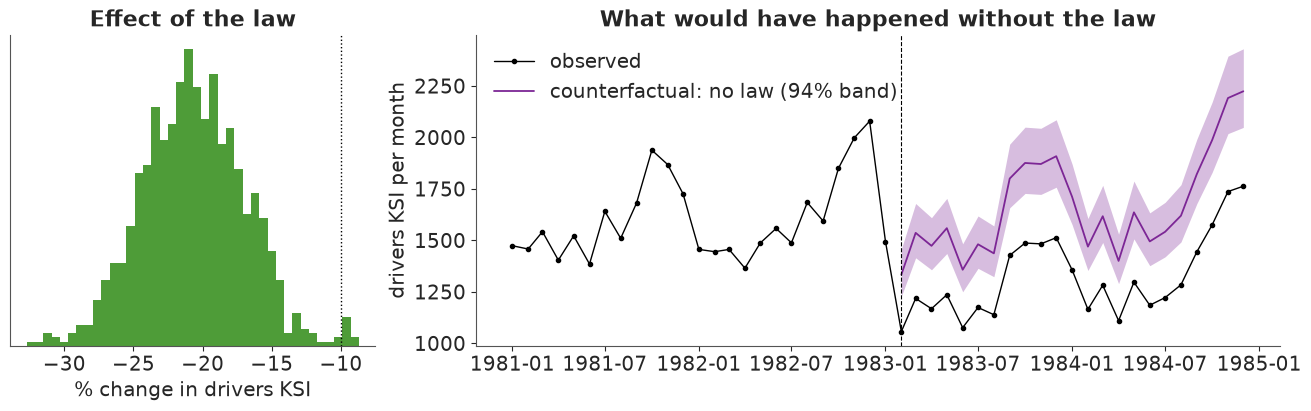

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), width_ratios=[1, 2.2])
axes[0].hist(pct, bins=40, color="C4", alpha=0.8)
axes[0].axvline(-10, color="k", ls=":", lw=1)
axes[0].set(title="Effect of the law", xlabel="% change in drivers KSI", yticks=[])

recent = belts.loc["1981":]
axes[1].plot(recent.index, recent.drivers, color="k", marker=".", lw=1, label="observed")
lo, mid, hi = np.quantile(counterfactual, [0.03, 0.5, 0.97], axis=0)
axes[1].fill_between(belts.index[post_law], lo, hi, color="C3", alpha=0.3, lw=0)
axes[1].plot(belts.index[post_law], mid, color="C3", lw=1.3, label="counterfactual: no law (94% band)")
axes[1].axvline(LAW_START, color="k", ls="--", lw=0.8)
axes[1].set(title="What would have happened without the law", ylabel="drivers KSI per month")
axes[1].legend(loc="upper left");

**The answer.** The law cut the number of car drivers killed or seriously injured by about
**21%** (94% interval roughly 14% to 28%). A reduction is certain as far as this model is
concerned, a reduction of more than 10% has probability 0.99, and "more than 20%" is
close to a coin flip. Over the 23 months to December 1984 that is about **8,000 fewer drivers
killed or seriously injured** (94% interval about 5,000 to 11,600), some 350 a month, against
the 30,399 who were.

This agrees with the classical maximum-likelihood analyses of the same series: Commandeur &
Koopman's textbook treatment (2007, a level + seasonal + petrol price + intervention model)
reports a coefficient of about -0.24, a fall of about 21%.

What the number does and does not mean:

- It is the effect **at fixed distance driven and petrol price**. If belts made people drive
  more, that pathway is excluded.
- It assumes a **step**. The innovations after the law gave no reason to doubt that.
- It counts drivers only. Front-seat passengers were covered by the law too (`front`).
- It inherits the identifying assumption of section 7: nothing else shifted the level
  abruptly in February 1983. That one can be probed.

### A negative-control outcome: rear-seat passengers

An intervention analysis on one series cannot distinguish "the law worked" from "something
else changed in February 1983" - a mild winter, a recession, a change in how injuries were
recorded. A **negative control** is an outcome exposed to all of those but *not* to the
intervention. Rear-seat passengers ride in the same cars on the same roads in the same
weather, and the 1983 law did not require them to wear a belt. Same model, same priors (the
initial level re-centred on a series four to five times smaller).

NUTS[nutpie]: [sigma_level, sigma_seasonal, sigma_obs]


posterior means: {'sigma_level': 0.0158, 'sigma_seasonal': 0.0047, 'sigma_obs': 0.0924}
wall-clock 40 s, divergences 0, max r_hat 1.002, min bulk ESS 1835


Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


change in REAR-seat passengers KSI at the law: mean 0.4%, 94% HDI [-9.0, 9.5]%
P(reduction > 10%) = 0.016


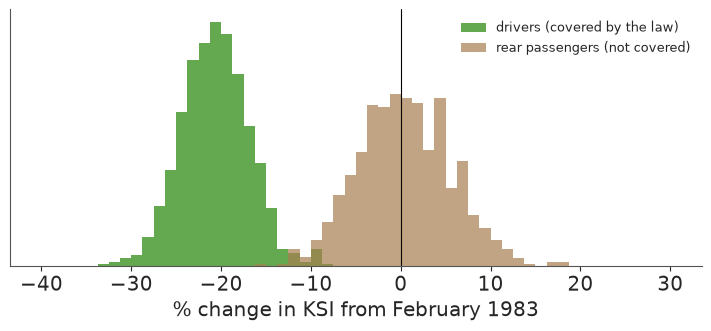

In [26]:
model_rear = make_model(y_rear, np.log(400.0), LAW_PRIOR_SD)
idata_rear, wall_rear = fit(model_rear)
print("posterior means:", {v: round(float(idata_rear.posterior[v].mean()), 4) for v in SIGMAS})
print(f"wall-clock {wall_rear:.0f} s, divergences {int(idata_rear.sample_stats['diverging'].sum())}, "
      f"max r_hat {max(float(az.rhat(idata_rear, var_names=SIGMAS)[v].max()) for v in SIGMAS):.3f}, "
      f"min bulk ESS {min(float(az.ess(idata_rear, var_names=SIGMAS)[v].min()) for v in SIGMAS):.0f}")

states_rear, _ = smooth(idata_rear, every=4)
lam_rear = states_rear[:, -1, STATE_NAMES.index("law")]
del states_rear, idata_rear

report("change in REAR-seat passengers KSI at the law", 100 * (np.exp(lam_rear) - 1), "%")
print(f"P(reduction > 10%) = {np.mean(100 * (np.exp(lam_rear) - 1) < -10):.3f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
bins = np.linspace(-40, 30, 57)
ax.hist(pct, bins=bins, alpha=0.7, color="C4", density=True, label="drivers (covered by the law)")
ax.hist(100 * (np.exp(lam_rear) - 1), bins=bins, alpha=0.7, color="C7", density=True,
        label="rear passengers (not covered)")
ax.axvline(0, color="k", lw=0.8)
ax.set(xlabel="% change in KSI from February 1983", yticks=[])
ax.legend(fontsize=9);

The same model that finds a 21% fall for drivers finds **nothing** for rear-seat passengers:
a change centred on zero (+0.4%), with a 94% interval of roughly -9% to +10% and a probability
of about 0.02 that they fell by more than 10%. Whatever happened in February 1983 happened to
the people the law applied to and not to the people sitting behind them. A mild winter, a
recession or a change in injury recording would have hit both.

Two honest limits. The rear series is four to five times smaller and noisier (`sigma_obs` of
0.09 against 0.06), so the interval is wide: this rules out a *common* shock of -21%, not a
modest effect in either direction - including the small **increase** that the
risk-compensation argument predicts (belted drivers taking more risks, unbelted passengers
paying for it). And a negative control can only fail to
falsify; it does not prove the mechanism.

## 10 · Two things the Kalman filter gives you for free

### Missing observations

If $y_t$ is missing, the filter simply skips the update step for that month: the prediction
becomes the filtered estimate, and the uncertainty $P_t$ keeps growing until data return. No
imputation model, no extra parameters. In `pymc_extras` you mark missing values as **NaN** in
the data frame; the package warns that it will treat them as hidden states, replaces them by
a sentinel internally and masks them in the filter.

To see it work, blank out 18 months (January 1977 - June 1978), refit, and compare the
smoother's reconstruction with what really happened.

In [27]:
gap = slice("1977-01-01", "1978-06-01")
y_gap = y_drivers.copy()
y_gap.loc[gap] = np.nan

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    model_gap = make_model(y_gap, np.log(1500.0), LAW_PRIOR_SD)
print("package warning:", [str(w.message) for w in caught if "missing" in str(w.message)][0])

idata_gap, wall_gap = fit(model_gap)
print(f"wall-clock {wall_gap:.0f} s, divergences {int(idata_gap.sample_stats['diverging'].sum())}, "
      f"max r_hat {max(float(az.rhat(idata_gap, var_names=SIGMAS)[v].max()) for v in SIGMAS):.3f}")

states_gap, yrep_gap = smooth(idata_gap, every=4)
level_g, seasonal_g, _, contrib_g = components(states_gap, exog.to_numpy())
signal_gap = level_g + seasonal_g + contrib_g.sum(axis=2)
del states_gap, idata_gap

package warning: Provided data contains missing values and will be automatically imputed as hidden states during Kalman filtering.


NUTS[nutpie]: [sigma_level, sigma_seasonal, sigma_obs]


wall-clock 43 s, divergences 0, max r_hat 1.003


Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


94% band width of the smoothed signal: inside the gap 0.195, same months with full data 0.109, observed months of the gap fit 0.117
held-out months inside the 94% predictive interval: 18 of 18


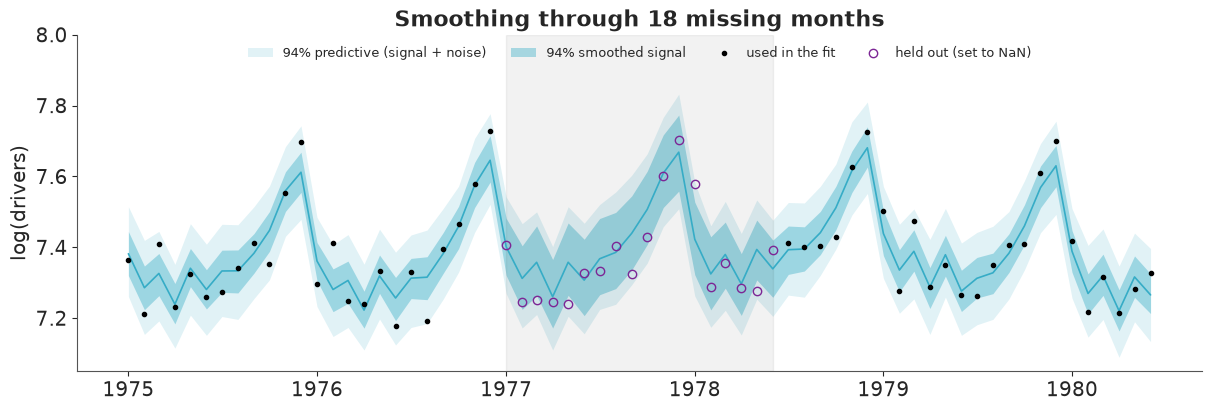

In [28]:
in_gap = (y_drivers.index >= gap.start) & (y_drivers.index <= gap.stop)
near = (y_drivers.index >= "1975-01-01") & (y_drivers.index <= "1980-06-01")


def width(draws):
    lo, hi = np.quantile(draws, [0.03, 0.97], axis=0)
    return hi - lo


print(f"94% band width of the smoothed signal: inside the gap {width(signal_gap)[in_gap].mean():.3f}, "
      f"same months with full data {width(signal)[in_gap].mean():.3f}, "
      f"observed months of the gap fit {width(signal_gap)[near & ~in_gap].mean():.3f}")
lo_y, hi_y = np.quantile(yrep_gap, [0.03, 0.97], axis=0)
covered = (y_np[in_gap] >= lo_y[in_gap]) & (y_np[in_gap] <= hi_y[in_gap])
print(f"held-out months inside the 94% predictive interval: {covered.sum()} of {in_gap.sum()}")

fig, ax = plt.subplots(figsize=(12, 4))
t = y_drivers.index[near]
ax.fill_between(t, lo_y[near], hi_y[near], color="C0", alpha=0.15, lw=0, label="94% predictive (signal + noise)")
lo_s, mid_s, hi_s = np.quantile(signal_gap[:, near], [0.03, 0.5, 0.97], axis=0)
ax.fill_between(t, lo_s, hi_s, color="C0", alpha=0.4, lw=0, label="94% smoothed signal")
ax.plot(t, mid_s, color="C0", lw=1.2)
ax.plot(y_drivers.index[near & ~in_gap], y_np[near & ~in_gap], ".", color="k", label="used in the fit")
ax.plot(y_drivers.index[in_gap], y_np[in_gap], "o", mfc="none", color="C3", label="held out (set to NaN)")
ax.axvspan(pd.Timestamp(gap.start), pd.Timestamp(gap.stop), color="k", alpha=0.05)
ax.set(ylabel="log(drivers)", ylim=(7.05, 8.0), title="Smoothing through 18 missing months")
ax.legend(ncol=4, fontsize=9, loc="upper center");
del yrep_gap

The reconstruction is not a straight line across the gap. The seasonal states keep rotating
while no data arrive, so the December 1977 peak is where it should be, and because this is the
*smoother* the level is pinned from both sides - by 1976 and by late 1978. The price of 18
months without data is visible in the dark band: its width inside the gap is about 0.20
against 0.11 for the same months when they are observed (and 0.12 for the observed months of
this fit). The outer band adds the irregular noise and is the one to compare with data: all
18 held-out months fall inside it. The refit itself was unremarkable (no divergences,
`r_hat` 1.00), and needed no change to the model - only NaNs in the data.

### Forecasting

A forecast is the filter's predict step applied repeatedly with no updates: the last state
estimate is pushed through $T$, and every step adds another $Q$ to the state covariance, so
the uncertainty **grows with the horizon** in exactly the way the model implies.
`ss_mod.forecast` does this for each posterior draw. Because the model has regressors, it
insists on a **scenario** for them: here petrol stays at its December 1984 price, distance
driven repeats its last twelve months, and the law stays in force.

Sampling: [forecast_combined]


Jan 1985 (h= 1): median 1,390, 94% interval [1,178, 1,596], sd on the log scale 0.077
Dec 1985 (h=12): median 1,745, 94% interval [1,455, 2,140], sd on the log scale 0.100
Dec 1986 (h=24): median 1,752, 94% interval [1,387, 2,170], sd on the log scale 0.117


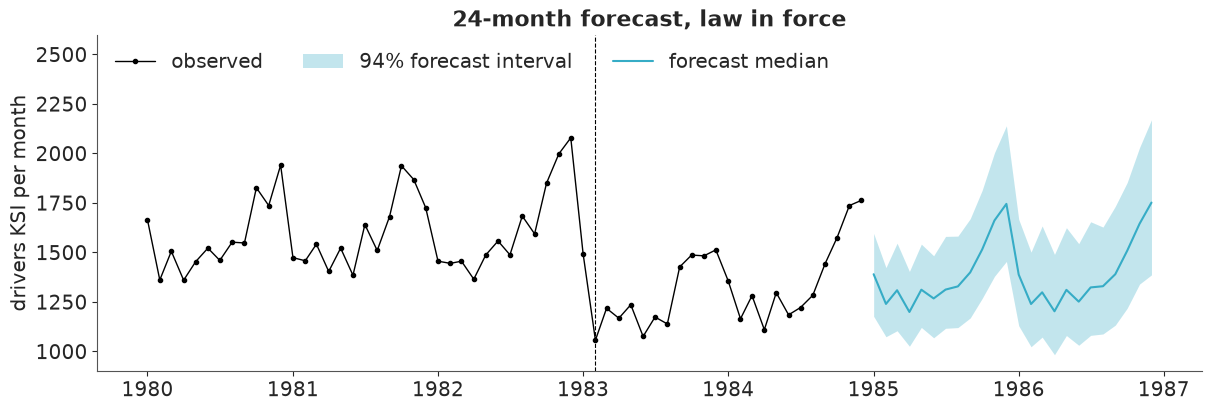

In [29]:
H = 24
future = pd.date_range(y_drivers.index[-1], periods=H + 1, freq="MS")[1:]
scenario = pd.DataFrame(
    {
        "log_petrol": exog.log_petrol.iloc[-1],
        "log_kms": np.tile(exog.log_kms.iloc[-12:].to_numpy(), 2),
        "law": 1.0,
    },
    index=future,
)
forecast = ss_mod.forecast(
    idata.isel(draw=slice(None, None, 4)), start=y_drivers.index[-1], periods=H,
    scenario={"data_exog": scenario}, random_seed=RANDOM_SEED, verbose=False,
)
fc = forecast["forecast_observed"].isel(observed_state=0).stack(sample=("chain", "draw"))
fc = fc.transpose("sample", "time")
assert (fc.time.values == future.values).all()
fc = fc.values
del forecast

fc_sd = fc.std(axis=0)
lo, mid, hi = np.exp(np.quantile(fc, [0.03, 0.5, 0.97], axis=0))
for h in (1, 12, 24):
    print(f"{future[h - 1]:%b %Y} (h={h:>2}): median {mid[h - 1]:,.0f}, 94% interval "
          f"[{lo[h - 1]:,.0f}, {hi[h - 1]:,.0f}], sd on the log scale {fc_sd[h - 1]:.3f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(belts.loc["1980":].index, belts.loc["1980":, "drivers"], color="k", lw=1, marker=".", label="observed")
ax.fill_between(future, lo, hi, color="C0", alpha=0.3, lw=0, label="94% forecast interval")
ax.plot(future, mid, color="C0", label="forecast median")
ax.axvline(LAW_START, color="k", ls="--", lw=0.8)
ax.set(ylabel="drivers KSI per month", ylim=(900, 2600), title="24-month forecast, law in force")
ax.legend(loc="upper left", ncol=3);

The forecast repeats the seasonal pattern around the last estimated level, with the law
still switched on. The predictive standard deviation on the log scale grows from about 0.08
one month ahead to 0.10 at twelve months and 0.12 at twenty-four: one month ahead it is mostly
irregular noise plus uncertainty about the current level, and each further month adds another
`sigma_level`-sized step of the random walk. In drivers, the 94% interval for December 1986
runs from about 1,400 to 2,200 around a median of 1,750.

Two caveats. The interval is conditional on the **scenario**: uncertainty about future petrol
prices and traffic is not in it. And a local level model forecasts a flat level by
construction - if you believe in a drift, model a slope (exercise 1) and pay for it in wider
intervals.

## 11 · Limits, stated plainly

- **Linear and Gaussian, or nothing.** The exact marginal likelihood exists because every
  conditional distribution stays Gaussian. Monthly counts in the thousands are fine on the log
  scale; `VanKilled` (around ten a month) is not, and a Poisson observation equation needs an
  approximate filter, a particle filter, or brute force. **C07's stochastic volatility** has the
  latent state inside the *variance* of the observation - not linear-Gaussian - which is why it
  was sampled state by state. Heavy-tailed noise, regime switches and saturating effects break
  the assumption in the same way.
- **It is not fast.** Section 6: 40-50 s per fit for a three-parameter posterior, because
  the filter is a sequential `scan` and its gradient is expensive, and every new `pm.Model`
  (the rear-seat series, the series with a gap) is compiled again. The brute-force model was
  several times quicker on 192 observations. The Kalman filter's selling points here are
  geometry and exactness.
- **The API, as experienced with pymc-extras 0.15.1 on PyMC 6.3.2.** Everything used in this
  notebook worked. The friction:
  - Parameters are matched **by name**, and *you* must supply `P0` - there is no default and no
    diffuse initialisation, so the initial-state prior is always your decision.
  - Every parameter must end up in the posterior group: constants must be
    `pm.Deterministic`, not `pm.Data` ("Cannot sample from flat variable").
  - Regression coefficients are *states*. Integrating them out (our `P0` trick) means their
    posterior comes from the smoother; `extract_components_from_idata` returns the coefficient
    itself, not coefficient x regressor, so contributions are computed by hand.
  - Post-estimation is where memory goes: outputs are (draws x time x states) and covariances
    (draws x time x states x states). Thin first and name the outputs you want. The whole
    notebook peaks a little above 1 GB with 1000 thinned draws.
  - `mvn_method="cholesky"` fails for this model ("Matrix is not positive definite": constant
    coefficient states have singular smoothed covariances); the slow but safe default `"svd"`
    works.
  - Forecasting needs a `DatetimeIndex` with a frequency and an explicit scenario for the
    regressors.
  - `pm.compute_log_likelihood` works and returns one term per month, but each term is the
    one-step-ahead density $\log p(y_t \mid y_{1:t-1}, \theta)$. `az.loo` will run on it without
    complaint, yet it is **not** leave-one-out: $y_t$ also sits in the conditioning set of
    every later term. Treat the sum as a prequential score, or compare forecasts on held-out
    months.

### Try it yourself

1. **A stochastic slope.** Replace the level with `st.LevelTrend(order=2,
   innovations_order=[1, 1])` (a local linear trend). The model then asks for a two-element
   `initial_level` and `sigma_level`, and `P0` grows by one state. Does the law effect move?
   What happens to the 24-month forecast interval, and why is that the honest price of
   admitting the series might have a drift?
2. **A different model class, compared by forecast score.** Fit
   `pymc_extras.statespace.BayesianSARIMAX` with `order=(0, 1, 1)`, `seasonal_order=(0, 1, 1, 12)`
   (the "airline model") and the same regressors to the data up to December 1982, forecast
   1983-84 from both models with the law dummy in the scenario, and compare the log predictive
   density of the 24 held-out months. (Not `az.loo`: see the last bullet of the limits above. And compare only
   months after both filters have burnt in - a differenced model treats its first 13
   observations differently.)
3. **Front and rear jointly.** Give every component `observed_state_names=["front", "rear"]`
   and model the two series together, with a full covariance for the level shocks. The law
   coefficient becomes a 2-vector. Is the front-seat effect sharper once the shared
   month-to-month shocks are modelled? And is the rear-seat effect still indistinguishable
   from zero - or slightly *positive*, as the "risk compensation" argument would predict?

Next: **C07** for a latent time series that is *not* linear-Gaussian, or **E12** for what to
try when NUTS itself is the bottleneck.